In [1]:
# All the imports we need
import numpy as np
import gtsam
from gtsam.utils.plot import plot_pose3
from matplotlib import pyplot as plt
from gtsam.symbol_shorthand import B, V, X
from gtbook.display import show
from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
T = 12  # The timespan of our trajectory.
dt = 1e-2  # 100 Hz frequency
velocity = np.array([2, 0, 0])  # The velocity we wish to move at.

scenarios = {
    "zero_twist": (np.zeros(3), np.zeros(3)),  # Zero motion, stationary trajectory.
    "forward_motion": (np.zeros(3), velocity),  # Move forward in the x axis at 2 m/s.
    "loop": (np.array([0, -np.radians(30), 0]), velocity),  # A loop-de-loop trajectory.
    "sick": (np.array([np.radians(30), -np.radians(30), 0]), velocity)  # A spiral trajectory, "sick" in surfer slang.
}

def plot_scenario(scenario,
                  T,
                  dt,
                  title="IMU trajectory scenario",
                  fignum=0,
                  maxDim=5):
    for t in np.arange(0, T, dt):
        # print(f"t={t:.2f}s")
        actualPose = scenario.pose(t)
        plot_pose3(fignum, actualPose, axis_length=0.3)

        translation = actualPose.translation()
        maxDim = max([max(np.abs(translation)), maxDim])
        ax = plt.gca()
        ax.set_xlim3d(-maxDim, maxDim)
        ax.set_ylim3d(-maxDim, maxDim)
        ax.set_zlim3d(-maxDim, maxDim)
        ax.set_title(title)
    # print("Plot")
    plt.show()
# print test
# for name, (angular_velocity, linear_velocity) in scenarios.items():
#     print(f"Scenario: {name}")
#     print(f"  Angular Velocity (rad/s): {angular_velocity}")
#     print(f"  Linear Velocity (m/s): {linear_velocity}\n")

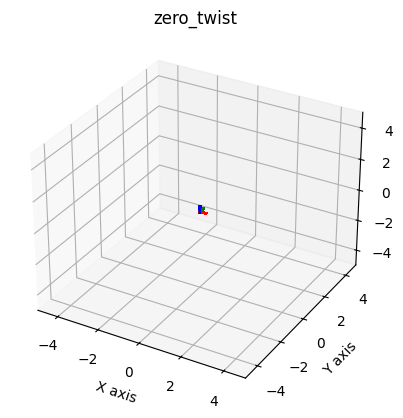

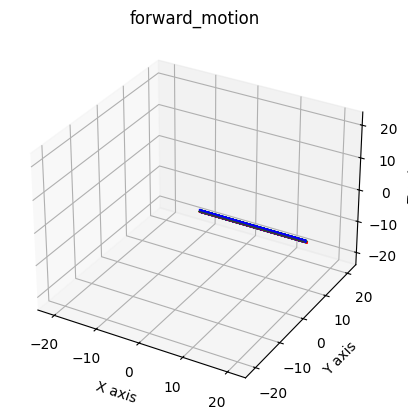

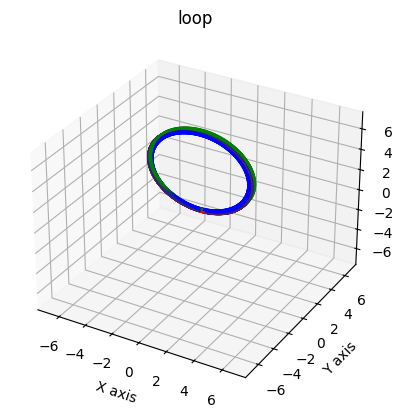

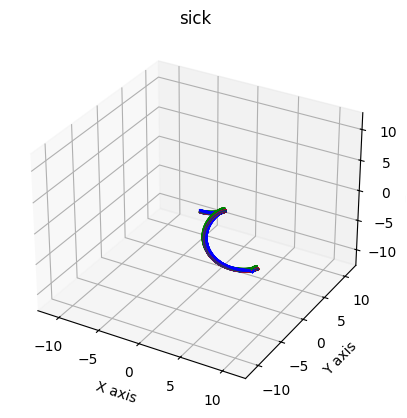

In [3]:
for idx, scenario_name in enumerate(scenarios.keys()):
    scenario = gtsam.ConstantTwistScenario(*scenarios[scenario_name])
    plot_scenario(scenario, T, dt, fignum=idx + 1, title=scenario_name)